In [5]:
from pyscf import gto, scf
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

# ── 1. Definisi molekul H₂ ─────────────────────────────────
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",  # jarak 0.735 Å (equilibrium)
    basis="sto-3g",
    charge=0,
    spin=0
)

problem = driver.run()

print(f"Jumlah orbital: {problem.num_spatial_orbitals}")
print(f"Jumlah elektron: {problem.num_particles}")
# Output: 2 orbital, (1 alpha, 1 beta) electron

Jumlah orbital: 2
Jumlah elektron: (1, 1)


In [8]:
mapper = JordanWignerMapper()

# Ambil FermionicOp dulu, BARU di-map
fermionic_op = problem.hamiltonian.second_q_op()
qubit_op = mapper.map(fermionic_op)

print(f"Jumlah qubit      : {qubit_op.num_qubits}")
print(f"Jumlah Pauli terms: {len(qubit_op)}")
print()
print("Pauli terms:")
for pauli, coeff in zip(qubit_op.paulis, qubit_op.coeffs):
    if abs(coeff.real) > 1e-10:  # filter term yang hampir nol
        print(f"  {pauli}  →  {coeff.real:.6f}")

Jumlah qubit      : 4
Jumlah Pauli terms: 15

Pauli terms:
  IIII  →  -0.810548
  IIIZ  →  0.172184
  IIZI  →  -0.225753
  IIZZ  →  0.120913
  IZII  →  0.172184
  IZIZ  →  0.168928
  ZIII  →  -0.225753
  ZIIZ  →  0.166145
  YYYY  →  0.045233
  XXYY  →  0.045233
  YYXX  →  0.045233
  XXXX  →  0.045233
  IZZI  →  0.166145
  ZIZI  →  0.174643
  ZZII  →  0.120913


In [9]:
# ── 4. Initial state: Hartree-Fock ──────────────────────────
# HF state = solusi klasik terbaik, titik awal VQE
hf_state = HartreeFock(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper
)

# ── 5. Ansatz: UCCSD di atas HF state ───────────────────────
ansatz = UCCSD(
    num_spatial_orbitals=problem.num_spatial_orbitals,
    num_particles=problem.num_particles,
    qubit_mapper=mapper,
    initial_state=hf_state
)

print(f"Jumlah parameter ansatz: {ansatz.num_parameters}")
ansatz.decompose().draw("text")  # lihat circuit-nya

Jumlah parameter ansatz: 3


┌───┐┌───────────────────────────────┐┌───────────────────────────────┐»
q_0: ┤ X ├┤0                              ├┤0                              ├»
     └───┘│                               ││                               │»
q_1: ─────┤1                              ├┤1                              ├»
     ┌───┐│  exp(-it (IIXY + IIYX))(t[0]) ││  exp(-it (XYII + YXII))(t[1]) │»
q_2: ┤ X ├┤2                              ├┤2                              ├»
     └───┘│                               ││                               │»
q_3: ─────┤3                              ├┤3                              ├»
          └───────────────────────────────┘└───────────────────────────────┘»
«     ┌─────────────────────────────────────────────────────────────────────────┐
«q_0: ┤0                                                                        ├
«     │                                                                         │
«q_1: ┤1                                                                        ├
«     │  exp(-it (YYXY + XYYY + XXXY + YXYY + XYXX + YYYX + YXXX + XXYX))(t[2]) │
«q_2: ┤2                                                                        ├
«     │                                                                         │
«q_3: ┤3                                                                        ├
«     └─────────────────────────────────────────────────────────────────────────┘

In [10]:
from qiskit_algorithms.optimizers import COBYLA, SLSQP, L_BFGS_B

# Untuk simulasi klasik: L-BFGS-B paling efisien
# Untuk real hardware / noisy: COBYLA lebih robust

optimizer = L_BFGS_B(maxiter=1000)

# Alternatif jika noise:
# optimizer = COBYLA(maxiter=500, rhobeg=0.1)

In [11]:
from qiskit_algorithms import VQE, SamplingVQE
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient

# ── 6. Estimator primitive ──────────────────────────────────
# StatevectorEstimator = simulasi eksak (tidak ada noise)
estimator = StatevectorEstimator()

# ── 7. Rakit VQE ────────────────────────────────────────────
vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    initial_point=None  # None = random init, atau bisa set manual
)

# ── 8. Solve! ───────────────────────────────────────────────
result = vqe.compute_minimum_eigenvalue(operator=qubit_op)

print("=" * 50)
print(f"VQE Energy     : {result.eigenvalue.real:.8f} Ha")
print(f"Parameter optimal: {result.optimal_parameters}")
print(f"Jumlah evaluasi: {result.cost_function_evals}")

/mgpfs/home/mkhairiansyah/.conda/envs/env-ml/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/mgpfs/home/mkhairiansyah/.conda/envs/env-ml/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


VQE Energy     : -1.85727503 Ha
Parameter optimal: {ParameterVectorElement(t[0]): np.float64(-1.1355211777639183e-06), ParameterVectorElement(t[1]): np.float64(1.5113339071140688e-06), ParameterVectorElement(t[2]): np.float64(-3.2533611253655725)}
Jumlah evaluasi: 56


In [12]:
from qiskit_algorithms import NumPyMinimumEigensolver

# FCI = solusi eksak (klasik, exponential cost)
# Ini benchmark kebenaran VQE kita
numpy_solver = NumPyMinimumEigensolver()
fci_result = numpy_solver.compute_minimum_eigenvalue(qubit_op)

vqe_energy = result.eigenvalue.real
fci_energy = fci_result.eigenvalue.real
error_hartree = abs(vqe_energy - fci_energy)
error_mHa     = error_hartree * 1000  # milli-Hartree

print("=" * 50)
print(f"VQE Energy : {vqe_energy:.8f} Ha")
print(f"FCI Energy : {fci_energy:.8f} Ha")
print(f"Error      : {error_mHa:.4f} mHa")
print()

# Chemical accuracy = < 1 mHa (1.6 kcal/mol)
if error_mHa < 1.0:
    print("✅ CHEMICAL ACCURACY TERCAPAI!")
else:
    print("⚠️  Belum chemical accuracy, cek ansatz/optimizer")

VQE Energy : -1.85727503 Ha
FCI Energy : -1.85727503 Ha
Error      : 0.0000 mHa

✅ CHEMICAL ACCURACY TERCAPAI!


/mgpfs/home/mkhairiansyah/.conda/envs/env-ml/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/mgpfs/home/mkhairiansyah/.conda/envs/env-ml/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


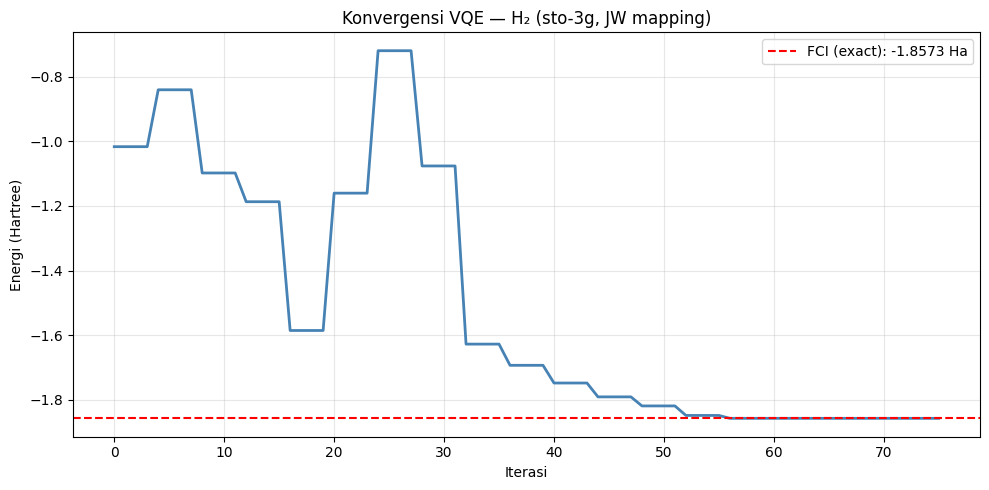

In [15]:
import matplotlib.pyplot as plt

# Tracking energi per iterasi
energy_history = []

def callback(nfev, x, fx, dx):
    energy_history.append(fx)

vqe_tracked = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)
result_tracked = vqe_tracked.compute_minimum_eigenvalue(qubit_op)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(energy_history, color='steelblue', linewidth=2)
plt.axhline(y=fci_energy, color='red', linestyle='--',
            label=f'FCI (exact): {fci_energy:.4f} Ha')
plt.xlabel("Iterasi")
plt.ylabel("Energi (Hartree)")
plt.title("Konvergensi VQE — H₂ (sto-3g, JW mapping)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("vqe_convergence_H2.png", dpi=150)
plt.show()